<a href="https://colab.research.google.com/github/SazzadHossain1461/Convolutional-Neural-Network/blob/Convolutional-Neural-Network/Convolutional_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install tensorflow-gpu

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [2]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [4]:
from tensorflow.keras.datasets import cifar10

In [5]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [6]:
class_names = ['0: airplan', '1: automobile', '2: bird', '3: cat', '4: dear', '5: dog', '6: frog', '7: horse', '8: ship', '9: truck']

In [7]:
print(class_names)

['0: airplan', '1: automobile', '2: bird', '3: cat', '4: dear', '5: dog', '6: frog', '7: horse', '8: ship', '9: truck']


In [8]:
x_train.max(), x_train.min(), x_train.mean()

(np.uint8(255), np.uint8(0), np.float64(120.70756512369792))

In [9]:
y_train.max(), y_train.min()

(np.uint8(9), np.uint8(0))

In [10]:
x_train = x_train/255.0
x_test = x_test/255.0

In [11]:
x_train.max(), x_train.min(), x_train.mean()

(np.float64(1.0), np.float64(0.0), np.float64(0.4733630004850874))

In [12]:
x_train.shape, x_test.shape

((50000, 32, 32, 3), (10000, 32, 32, 3))

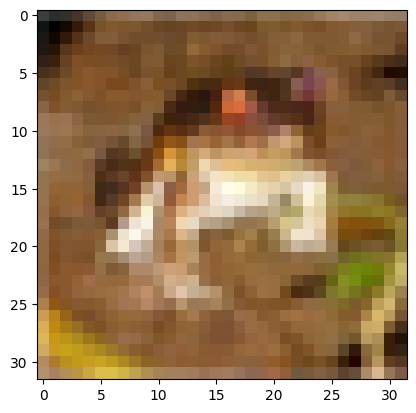

In [13]:
plt.imshow(x_train[0])

In [14]:
y_train[0]

array([6], dtype=uint8)

In [15]:
class_names

['0: airplan',
 '1: automobile',
 '2: bird',
 '3: cat',
 '4: dear',
 '5: dog',
 '6: frog',
 '7: horse',
 '8: ship',
 '9: truck']

In [16]:
model = tf.keras.models.Sequential()

In [17]:
model.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, padding='same', activation='relu', input_shape=[32, 32, 3]))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'))

model.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2, padding='valid'))

In [19]:
model.add(tf.keras.layers.Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))

In [20]:
model.add(tf.keras.layers.Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))

model.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2, padding='valid'))

In [21]:
model.add(tf.keras.layers.Dropout(0.4))

In [22]:
model.add(tf.keras.layers.Flatten())

In [23]:
model.add(tf.keras.layers.Dense(units=128, activation='relu'))

In [24]:
model.add(tf.keras.layers.Dense(units=10, activation='softmax'))

In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,274 (2.26 MB)

 Trainable params: 591,274 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['sparse_categorical_accuracy'])

In [28]:
model.fit(x_train, y_train, batch_size=10, epochs=10)

Epoch 1/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 282s 56ms/step - loss: 1.6663 - sparse_categorical_accuracy: 0.3854
Epoch 2/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 271s 54ms/step - loss: 1.0466 - sparse_categorical_accuracy: 0.6272
Epoch 3/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 273s 55ms/step - loss: 0.8840 - sparse_categorical_accuracy: 0.6849
Epoch 4/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 275s 55ms/step - loss: 0.7827 - sparse_categorical_accuracy: 0.7228
Epoch 5/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 332s 57ms/step - loss: 0.7109 - sparse_categorical_accuracy: 0.7520
Epoch 6/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 313s 55ms/step - loss: 0.6666 - sparse_categorical_accuracy: 0.7627
Epoch 7/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 281s 56ms/step - loss: 0.6273 - sparse_categorical_accuracy: 0.7776
Epoch 8/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 278s 56ms/step - loss: 0.5700 - sparse_categorical_accuracy: 0.7975
Epoch 9/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 274s 55ms/step - loss: 0.5471 - sparse_categorical_accuracy: 0.8064
Epoch 10/1

In [29]:
test_loss, test_acc = model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - loss: 0.7460 - sparse_categorical_accuracy: 0.7513


In [30]:
print('Test Accuracy is: {}'.format(test_acc))

Test Accuracy is: 0.7469000220298767


In [33]:
y_pred = np.argmax(model.predict(x_test), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step


In [37]:
print(y_pred[102]), print(y_test[102])

6
[6]


(None, None)

In [38]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[754  14  45  34  13   2   7  14  98  19]
 [ 14 887   3   2   1   2   6   0  36  49]
 [ 75   7 557 104  64  67  66  37  17   6]
 [ 22   9  40 607  27 171  52  40  21  11]
 [ 23   3  61 109 603  38  76  75   8   4]
 [  8   2  28 169  22 702  26  34   8   1]
 [  4   4  23  71  12  30 838   8   9   1]
 [ 11   2  28  42  36  47   6 801  14  13]
 [ 27  22   6   8   0   3   1   3 917  13]
 [ 27  96   3  14   1   2   4  15  35 803]]


In [39]:
acc_cm = accuracy_score(y_test, y_pred)
print(acc_cm)

0.7469
